The dataset is Optical Coherence Tomography (OCT) retinal images; these are medical images of retina in cross-section.

Usually there are classes like “Normal”, “DME”, “CNV”, “Drusen”, etc. (depending on dataset).

OCT images tend to have characteristic noise / artifacts (speckle), varying contrast, etc.

The dataset probably has class imbalance, possibly varying resolutions, maybe artifacts or variation in acquisition.

In [ ]:
# ========================================
# 1. Libraries & Setup
# ========================================
import os
import kagglehub
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# ========================================
# 2. Download Dataset using KaggleHub
# ========================================
path = kagglehub.dataset_download("obulisainaren/retinal-oct-c8")
print("Dataset downloaded to:", path)


Using Colab cache for faster access to the 'retinal-oct-c8' dataset.
Dataset downloaded to: /kaggle/input/retinal-oct-c8


In [ ]:

# ========================================
# 3. Custom Dataset Class
# ========================================
class RetinalOCTDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            for img_name in os.listdir(cls_dir):
                img_path = os.path.join(cls_dir, img_name)
                self.samples.append((img_path, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


In [ ]:
# ========================================
# 4. Preprocessing / Transformations
# ========================================
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = RetinalOCTDataset(os.path.join(path, "RetinalOCT_Dataset/RetinalOCT_Dataset/train"), transform=train_transform)
val_dataset   = RetinalOCTDataset(os.path.join(path, "RetinalOCT_Dataset/RetinalOCT_Dataset/val"), transform=val_transform)
test_dataset  = RetinalOCTDataset(os.path.join(path, "RetinalOCT_Dataset/RetinalOCT_Dataset/test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']


In [ ]:
# ========================================
# 5. Model Definition
# ========================================
class RetinalNet(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super(RetinalNet, self).__init__()
        self.base = models.resnet18(pretrained=True)
        self.base.fc = nn.Linear(self.base.fc.in_features, num_classes)

    def forward(self, x):
        return self.base(x)

model = RetinalNet().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# ========================================
# 6. Training Setup
# ========================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 5

# Training Loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/5, Loss: 0.2679
Epoch 2/5, Loss: 0.1338
Epoch 3/5, Loss: 0.1050
Epoch 4/5, Loss: 0.0977
Epoch 5/5, Loss: 0.0835


In [ ]:
import pickle
with open('ResModel.pkl','wb') as f:
    pickle.dump(model,f)

In [ ]:
with open('ResModel.pkl','rb') as f:
    model1=pickle.load(f)

In [ ]:
# ========================================
# 7. Evaluation
# ========================================
model1.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model1(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))


              precision    recall  f1-score   support

         AMD       1.00      1.00      1.00       350
         CNV       0.96      0.90      0.93       350
         CSR       1.00      1.00      1.00       350
         DME       0.92      0.95      0.94       350
          DR       1.00      1.00      1.00       350
      DRUSEN       0.92      0.91      0.92       350
          MH       1.00      1.00      1.00       350
      NORMAL       0.91      0.97      0.94       350

    accuracy                           0.97      2800
   macro avg       0.97      0.97      0.97      2800
weighted avg       0.97      0.97      0.97      2800



In [ ]:
# ========================================
# 8. Grad-CAM Implementation
# ========================================
class GradCAM:
  def __init__(self, model, target_layer):
    self.model1 = model1
    self.gradients = None
    self.activations = None
    target_layer.register_forward_hook(self.save_activation)
    target_layer.register_full_backward_hook(self.save_gradient)

  def save_activation(self, module, input, output):
    self.activations = output
  def save_gradient(self, module, grad_input, grad_output):
    self.gradients = grad_output[0]
  def __call__(self, x, class_idx=None):
    x = x.to(device)
    output = self.model1(x)
    if class_idx is None:
      class_idx = output.argmax(dim=1).item()
    self.model1.zero_grad()
    output[0, class_idx].backward()
    grads = self.gradients.mean(dim=[2,3], keepdim=True)
    cam = F.relu((grads * self.activations).sum(dim=1)).squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam
  target_layer = model1.base.layer4[1].conv2
  grad_cam = GradCAM(model1, target_layer)


In [ ]:

# ========================================
# 9. ROI Segmentation + Feature Extraction
# ========================================
def extract_roi_and_features(img_tensor, cam):
    img_np = img_tensor.squeeze().permute(1,2,0).cpu().numpy()
    img_np = (img_np * 0.5 + 0.5) * 255
    img_np = img_np.astype(np.uint8)

    # Ensure the image array is contiguous
    img_np_copy = np.ascontiguousarray(img_np)

    heatmap = cv2.resize(cam, (img_np_copy.shape[1], img_np_copy.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    _, thresh = cv2.threshold(heatmap, 150, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    roi_features = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        roi = img_np_copy[y:y+h, x:x+w]

        # Extract features: mean color, area, aspect ratio
        mean_color = roi.mean(axis=(0, 1))
        area = w * h
        aspect_ratio = w / h if h != 0 else 0

        roi_features.append([mean_color[0], mean_color[1], mean_color[2], area, aspect_ratio])

        # Draw ROI on the contiguous copy
        cv2.rectangle(img_np_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)

    return img_np_copy, roi_features


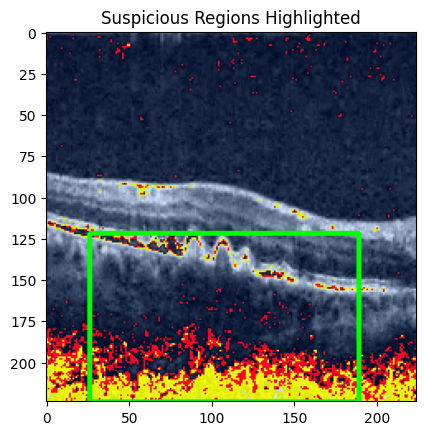

ROI Features saved to roi_features.csv
       Mean_R     Mean_G     Mean_B   Area  Aspect_Ratio
0  100.020089  82.830266  74.100686  16626      1.598039


In [ ]:
# Demo on one image
sample_img, _ = test_dataset[0]
sample_input = sample_img.unsqueeze(0)
cam = grad_cam(sample_input)

highlighted, features = extract_roi_and_features(sample_input, cam)
plt.imshow(highlighted)
plt.title("Suspicious Regions Highlighted")
plt.show()

# Save features to CSV
df_features = pd.DataFrame(features, columns=["Mean_R","Mean_G","Mean_B","Area","Aspect_Ratio"])
df_features.to_csv("roi_features.csv", index=False)
print("ROI Features saved to roi_features.csv")
print(df_features.head())


In [ ]:
df_features

,Mean_R,Mean_G,Mean_B,Area,Aspect_Ratio
0,100.020089,82.830266,74.100686,16626,1.598039


### FE only with test data

In [ ]:
# ========================================
# 10. Extract Features from Entire Dataset
# ========================================

from tqdm import tqdm
all_features = []
all_labels_feat = []

for idx in tqdm(range(len(test_dataset))):
    img, label = test_dataset[idx]
    input_img = img.unsqueeze(0)
    cam = grad_cam(input_img)

    highlighted, features = extract_roi_and_features(input_img, cam)

    # Append features with label
    for f in features:
        all_features.append(f)
        all_labels_feat.append(label)

# Convert to DataFrame
df_features = pd.DataFrame(all_features, columns=["Mean_R","Mean_G","Mean_B","Area","Aspect_Ratio"])
df_features["Label"] = all_labels_feat
df_features.to_csv("roi_features_test.csv", index=False)
print("Saved ALL ROI features:", df_features.shape)
print(df_features.head())



100%|██████████| 2800/2800 [00:46<00:00, 60.19it/s]


Saved ALL ROI features: (2952, 6)
       Mean_R      Mean_G      Mean_B   Area  Aspect_Ratio  Label
0  100.020089   82.830266   74.100686  16626      1.598039      0
1  103.855434  113.257527  124.639581  10030      1.388235      0
2   51.686065   64.612185   90.882075  17596      0.638554      0
3   49.414798   61.231551   87.241454  15651      0.787234      0
4   57.656474   72.614482  100.782090  24790      0.724324      0


In [ ]:
print(df_features)

          Mean_R      Mean_G      Mean_B   Area  Aspect_Ratio  Label
0     100.020089   82.830266   74.100686  16626      1.598039      0
1     103.855434  113.257527  124.639581  10030      1.388235      0
2      51.686065   64.612185   90.882075  17596      0.638554      0
3      49.414798   61.231551   87.241454  15651      0.787234      0
4      57.656474   72.614482  100.782090  24790      0.724324      0
...          ...         ...         ...    ...           ...    ...
2947  151.430750  148.948289  143.846567  18816      1.500000      7
2948  137.172993  133.505482  128.748313  11856      1.096154      7
2949  150.078731  147.702458  140.444390  18468      1.421053      7
2950  145.456903  138.737382  114.902858  12878      1.457447      7
2951  144.284789  137.065494  108.932372  13589      1.186916      7

[2952 rows x 6 columns]


In [ ]:

# ========================================
# 11. Classification using Extracted Features
# ========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df_features.drop("Label", axis=1)
y = df_features["Label"]

# Split into train/test for feature-based classification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

print("\nFeature-based Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)



Feature-based Classification Report:
              precision    recall  f1-score   support

         AMD       0.99      0.97      0.98        80
         CNV       0.54      0.42      0.47        72
         CSR       0.68      0.77      0.72        73
         DME       0.37      0.44      0.40        72
          DR       0.48      0.45      0.46        71
      DRUSEN       0.52      0.42      0.47        76
          MH       0.39      0.34      0.36        71
      NORMAL       0.39      0.50      0.44        76

    accuracy                           0.54       591
   macro avg       0.54      0.54      0.54       591
weighted avg       0.55      0.54      0.54       591

Confusion Matrix:
 [[78  0  0  0  1  0  1  0]
 [ 0 30  2 12  1  9  2 16]
 [ 0  4 56  4  3  1  2  3]
 [ 0  1  0 32  6  4 11 18]
 [ 0  5  7  3 32  5 12  7]
 [ 1 10  4 10  2 32  5 12]
 [ 0  1 11 10 19  3 24  3]
 [ 0  5  2 16  3  7  5 38]]


In [ ]:


# ========================================
# 12. Save Model for Future Use
# ========================================
import joblib
joblib.dump(clf_test, "feature_classifier_test.pkl")
print("Feature classifier saved as feature_classifier_test.pkl")

# To load:
# clf_test = joblib.load("feature_classifier_test.pkl")


Feature classifier saved as feature_classifier.pkl


### merge train + val + test Feature Extraction

( so the feature classifier has more balanced training data;

 That would improve results a lot.)

In [ ]:
# ========================================
# 10. Extract Features from Train + Val + Test
# ========================================

from tqdm import tqdm

def extract_features_from_loader(dataset, dataset_name="set"):
    all_features, all_labels = [], []
    for idx in tqdm(range(len(dataset)), desc=f"Processing {dataset_name}"):
        img, label = dataset[idx]
        input_img = img.unsqueeze(0)
        cam = grad_cam(input_img)

        highlighted, features = extract_roi_and_features(input_img, cam)

        for f in features:
            all_features.append(f)
            all_labels.append(label)

    return all_features, all_labels

In [ ]:
# Extract for all splits
train_features, train_labels = extract_features_from_loader(train_dataset, "Train")
val_features, val_labels     = extract_features_from_loader(val_dataset, "Validation")
test_features, test_labels   = extract_features_from_loader(test_dataset, "Test")

# Combine
all_features = train_features + val_features + test_features
all_labels   = train_labels + val_labels + test_labels

# Save as CSV
df_features = pd.DataFrame(all_features, columns=["Mean_R","Mean_G","Mean_B","Area","Aspect_Ratio"])
df_features["Label"] = all_labels
df_features.to_csv("roi_features_all.csv", index=False)
print("Saved ALL ROI features:", df_features.shape)
print(df_features.head())


Processing Test: 100%|██████████| 2800/2800 [00:42<00:00, 65.38it/s]


Saved ALL ROI features: (26051, 6)
       Mean_R      Mean_G      Mean_B   Area  Aspect_Ratio  Label
0   50.769103   58.596176   86.733353  26462      1.541985      0
1  141.535039  155.600667  169.780868    899      1.068966      0
2   53.389788   62.446063   86.266631   5562      1.907407      0
3   79.190941   90.450412  112.601294  17000      1.088000      0
4  103.318737   79.932947   95.574211   9500      1.052632      0


In [ ]:
# Load pre-saved features instead of extracting again
df_features = pd.read_csv("roi_features_all.csv")
print("Loaded pre-saved features:", df_features.shape)
print(df_features.head())

In [ ]:
# ========================================
# 11. Feature-Based Classification
# ========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df_features.drop("Label", axis=1)
y = df_features["Label"]

# Split into train/test (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

print("\nFeature-based Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)



Feature-based Classification Report:
              precision    recall  f1-score   support

         AMD       0.95      0.96      0.96       677
         CNV       0.58      0.51      0.54       633
         CSR       0.66      0.73      0.69       654
         DME       0.42      0.42      0.42       624
          DR       0.44      0.40      0.42       619
      DRUSEN       0.47      0.44      0.46       675
          MH       0.43      0.40      0.42       621
      NORMAL       0.40      0.47      0.43       708

    accuracy                           0.55      5211
   macro avg       0.54      0.54      0.54      5211
weighted avg       0.55      0.55      0.54      5211

Confusion Matrix:
 [[651   4   4   2   2   2   7   5]
 [  5 323  40  50   9 113  12  81]
 [  6  23 478   6  26  27  52  36]
 [  2  28  23 262  65  37  63 144]
 [  1  12  52  78 247  31 145  53]
 [  9 103  33  44  19 300  23 144]
 [  7  15  68  60 153  26 250  42]
 [  4  46  26 127  41 105  28 331]]


In [ ]:
# ========================================
# 12. Save Feature Classifier for Future Use
# ========================================
import joblib
joblib.dump(clf_all, "feature_classifier_all.pkl")
print("Feature classifier saved as feature_classifier_all.pkl")

# To load later:
# clf_all = joblib.load("feature_classifier_all.pkl")


Feature classifier saved as feature_classifier.pkl


### Script for classifying new images

In [ ]:
import cv2
import torch
import joblib
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Load saved models
cnn_model = torch.load("ResModel.pth", map_location=device)   # Your trained ResNet18
cnn_model.eval()
clf = joblib.load("feature_classifier.pkl")                   # Random Forest on ROI features

# Grad-CAM setup (same as before)
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        x = x.to(device)
        output = self.model(x)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        grads = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = F.relu((grads * self.activations).sum(dim=1)).squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

target_layer = cnn_model.base.layer4[1].conv2
grad_cam = GradCAM(cnn_model, target_layer)

# Function to process new image
def classify_new_image(img_path, class_names):
    # Preprocess
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(img_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0)

    # Grad-CAM
    cam = grad_cam(img_tensor)

    # ROI + Features
    highlighted, features = extract_roi_and_features(img_tensor, cam)
    df_feat = pd.DataFrame(features, columns=["Mean_R","Mean_G","Mean_B","Area","Aspect_Ratio"])

    # Predict class using Random Forest
    preds = clf.predict(df_feat)
    final_class = np.bincount(preds).argmax()  # majority voting if multiple ROIs

    # Display result
    plt.imshow(highlighted)
    plt.title(f"Predicted: {class_names[final_class]}")
    plt.axis("off")
    plt.show()

    return class_names[final_class], df_feat

# Example usage
img_path = "new_oct_scan.jpg"  # Replace with your test OCT image
predicted_class, extracted_features = classify_new_image(img_path, class_names)
print("Final Prediction:", predicted_class)
print("Extracted Features:\n", extracted_features)


Abstract

This project builds an end-to-end pipeline for retinal disease analysis from OCT scans. A CNN (ResNet18) is trained for disease classification. Grad-CAM is used to compute class activation maps which are thresholded to produce pseudo-masks. Those pseudo-masks train a U-Net (weak supervision) that segments suspicious regions (ROI). From segmented ROIs we extract interpretable features (shape, intensity, GLCM texture). Those features are exported to CSV and used to train a RandomForest classifier — enabling an interpretable, feature-based decision branch in addition to the deep model. Grad-CAM and segmentation overlays provide visual explainability. The pipeline demonstrates robustness and interpretability desirable for clinical usage.



Introduction

Explain OCT, clinical importance, challenges (speckle noise, lack of segmentation labels), and motivation for both deep learning and feature-based interpretability.



Methodology

Data loading using kagglehub.

Preprocessing: resizing to 224×224, normalization, light augmentation (flip/rotate/jitter).

Train ResNet18 classifier on train/val split.

Generate Grad-CAM maps for all training images; threshold to create pseudo-masks.

Train U-Net on pseudo-masks (weak supervision) to learn ROI segmentation.

Segment test images with U-Net and extract features: area, perimeter, eccentricity, mean/std intensity, mean RGB, GLCM contrast/homogeneity/energy.

Save features to CSV and train a RandomForest on these features for a feature-based classifier.

Visualize Grad-CAM and UNet overlays for explainability.



Results

Provide classification metrics from ResNet test set.

Provide RandomForest metrics on extracted features.

Show examples of Grad-CAM + UNet overlays and the CSV of extracted features.



Conclusion & Future Work

Approach is practical when segmentation labels are missing.

The two-branch system (deep classifier + feature classifier) offers both performance and interpretability.

Future: better pseudo-mask refinement (CRF), ensembling, calibration & uncertainty estimates, clinical validation.